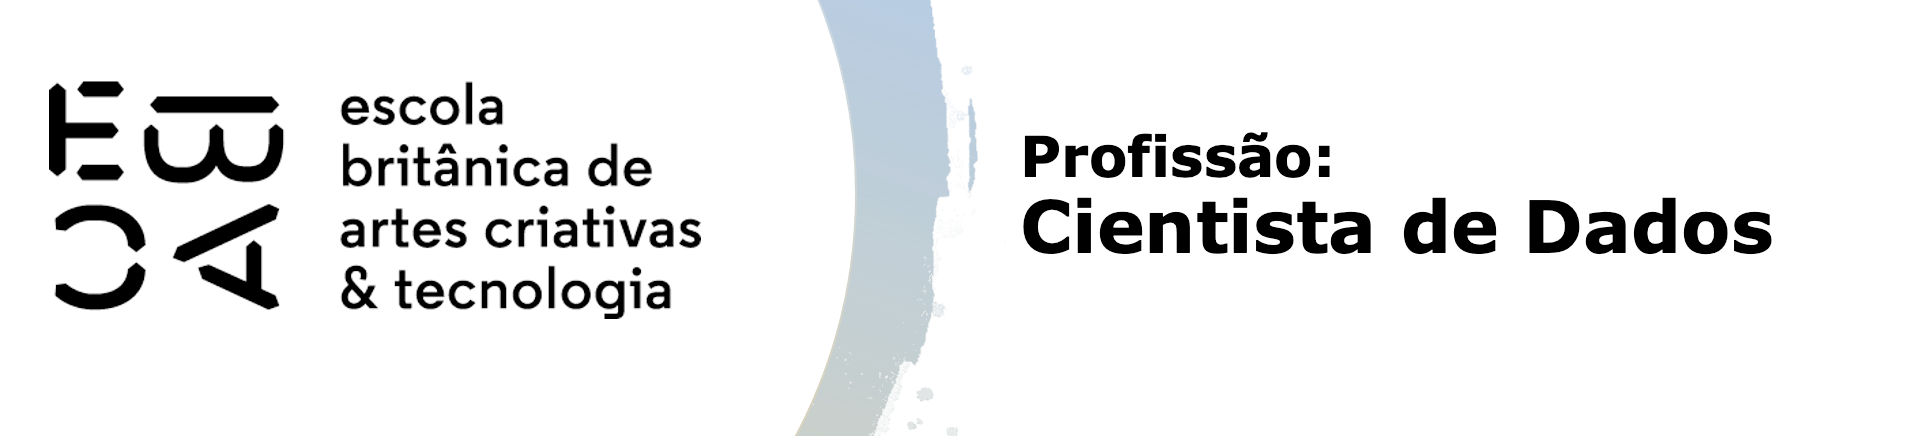

# Tarefa I

Neste projeto, estamos construindo um credit scoring para cartão de crédito, em um desenho amostral com 15 safras, e utilizando 12 meses de performance.

Carregue a base de dados ```credit_scoring.ftr```.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.utils import resample

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score, roc_curve


df = pd.read_feather('../Mod_35/credit_scoring.ftr')
df.head()

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,2015-01-01,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,False
1,2015-01-01,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,False
2,2015-01-01,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,False
3,2015-01-01,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,False
4,2015-01-01,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,False


## Amostragem

Separe os três últimos meses como safras de validação *out of time* (oot).

Variáveis:<br>
Considere que a variável ```data_ref``` não é uma variável explicativa, é somente uma variável indicadora da safra, e não deve ser utilizada na modelagem. A variávei ```index``` é um identificador do cliente, e também não deve ser utilizada como covariável (variável explicativa). As restantes podem ser utilizadas para prever a inadimplência, incluindo a renda.


In [2]:
data = df[df['data_ref'].dt.year == 2015].copy()
data_unseen = df[df['data_ref'].dt.year == 2016].copy()

print(f'Dimensões dos dados para treino do modelo: {data.shape}\nDimensões dos dados para validação do modelo (OOT): {data_unseen.shape}')

Dimensões dos dados para treino do modelo: (600000, 15)
Dimensões dos dados para validação do modelo (OOT): (150000, 15)


## Descritiva básica univariada

- Descreva a base quanto ao número de linhas, número de linhas para cada mês em ```data_ref```.
- Faça uma descritiva básica univariada de cada variável. Considere as naturezas diferentes: qualitativas e quantitativas.

In [3]:
# Classificar variáveis em qualitativas (discretas) e quantitativas (contínuas)
def classificar_variavel(variavel: pd.Series) -> str:
    '''
    Função para classificar uma variável em 'discreta' ou 'contínua'.

    Parâmetros:
    - variavel: recebe uma Serie do Pandas

    Retorna:
    - string identificando a variável
    '''
    try:
        num_classes = variavel.nunique()
        dtype = variavel.dtype
        if num_classes >= 6 and dtype in ['int64', 'float64']:
            return 'contínua'
        else:
            return 'discreta'
    except:
        return 'não identificado'
        

In [4]:
# Criando tabela com metadados
metadata = pd.DataFrame({'dtype': data.dtypes,
                         'num_missings': data.isna().sum(),
                         'num_classes': data.nunique(),
                         'tipo_variavel': [classificar_variavel(data[col]) for col in data],
                         'papel': 'independente'})

# Identificando variáveis que não utilizaremos
metadata.loc[metadata.index == 'data_ref', 'papel'] = 'não usar'
metadata.loc[metadata.index == 'index', 'papel'] = 'não usar'

# Identificando variável dependente
metadata.loc[metadata.index == 'mau', 'papel'] = 'dependente'

# Visualizando resultado
metadata

,dtype,num_missings,num_classes,tipo_variavel,papel
data_ref,datetime64[ns],0,12,discreta,não usar
index,int64,0,16650,contínua,não usar
sexo,object,0,2,discreta,independente
posse_de_veiculo,object,0,2,discreta,independente
posse_de_imovel,object,0,2,discreta,independente
qtd_filhos,int64,0,8,contínua,independente
tipo_renda,object,0,5,discreta,independente
educacao,object,0,5,discreta,independente
estado_civil,object,0,5,discreta,independente
tipo_residencia,object,0,6,discreta,independente


In [5]:
# Visualizando quantidade de registros por mês nos dados
data.groupby(by='data_ref', observed=False)['data_ref'].count()

data_ref
2015-01-01    50000
2015-02-01    50000
2015-03-01    50000
2015-04-01    50000
2015-05-01    50000
2015-06-01    50000
2015-07-01    50000
2015-08-01    50000
2015-09-01    50000
2015-10-01    50000
2015-11-01    50000
2015-12-01    50000
Name: data_ref, dtype: int64

In [6]:
# Definindo funções para conduzir análise univariada
def analise_univariada_quantitativa(variavel: pd.Series) -> None:
    '''
    Função para plotar a análise univariada de uma variável contínua.

    Parâmetros:
    - variavel: recebe o Series do Pandas da variável em questão
    '''
    tb = pd.DataFrame(variavel.describe().rename({'count': 'contagem', 'mean': 'média', 'std': 'desvio padrão'}))
    display(tb)

    variavel.plot(kind='hist', ylabel='Frequência', title='Histograma de {}'.format(variavel.name.capitalize()))
    plt.show()

def analise_univariada_qualitativa(variavel: pd.Series) -> None:
    '''
    Função para plotar a análise univariada de uma variável discreta.

    Parâmetros:
    - variavel: recebe o Series do Pandas da variável em questão
    '''
    tb = pd.DataFrame(variavel.value_counts(normalize=True)).rename({'proportion': 'Proporção'}, axis=1)
    display(tb)

    tb.plot(kind='bar', title='Proporção das Classes de {}'.format(variavel.name.capitalize()))
    plt.show()

def analise_univariada(variavel: pd.Series, tipo: str) -> None:
    '''
    Função para conduzir a análise univariada de acordo com o tipo da variável.

    
    Parâmetros:
    - variavel: recebe o Series do Pandas da variável em questão.
    - tipo: recebe o tipo da variável, entre 'discreta' e 'contínua'.
    '''
    if tipo not in ['discreta', 'contínua']:
        return 'Tipo da variável não aceito'
    if tipo == 'discreta':
        return analise_univariada_qualitativa(variavel)
    return analise_univariada_quantitativa(variavel)

,Proporção
sexo,
F,0.673008
M,0.326992


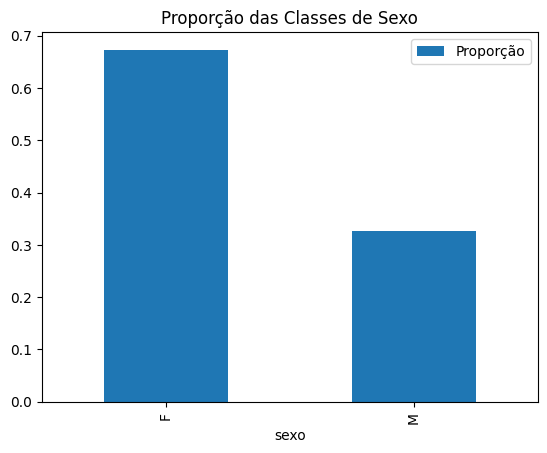

,Proporção
posse_de_veiculo,
N,0.610488
S,0.389512


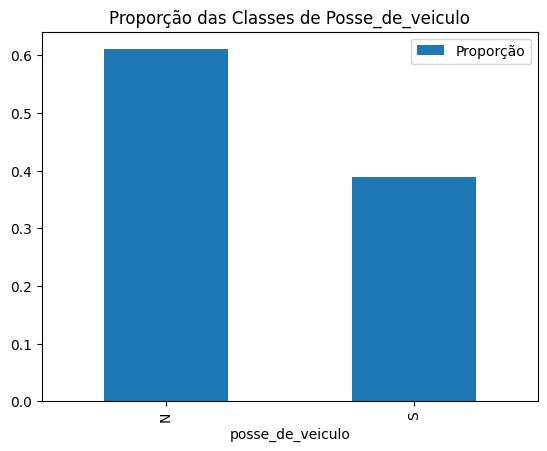

,Proporção
posse_de_imovel,
S,0.671757
N,0.328243


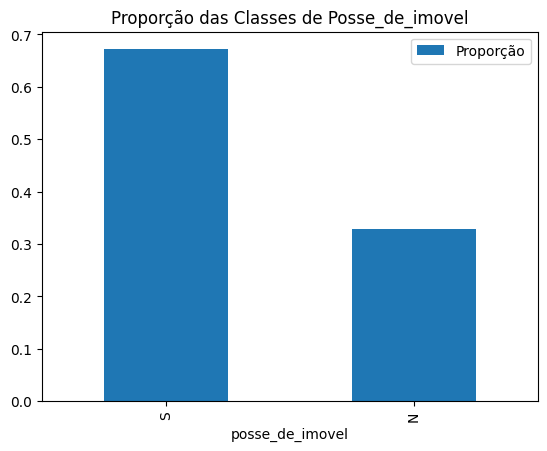

,qtd_filhos
contagem,600000.000000
média,0.433210
desvio padrão,0.739869
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,14.000000


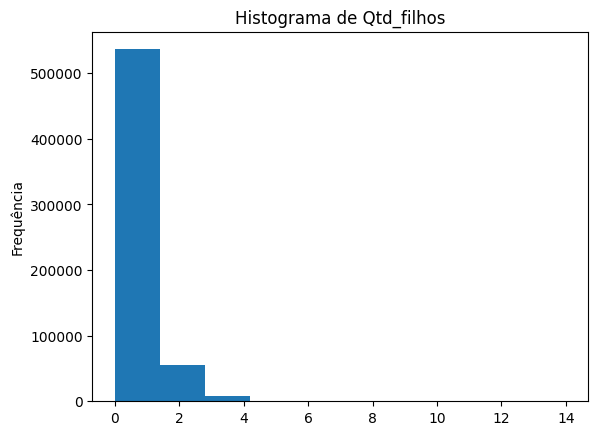

,Proporção
tipo_renda,
Assalariado,0.514100
Empresário,0.230235
Pensionista,0.168545
Servidor público,0.086635
Bolsista,0.000485


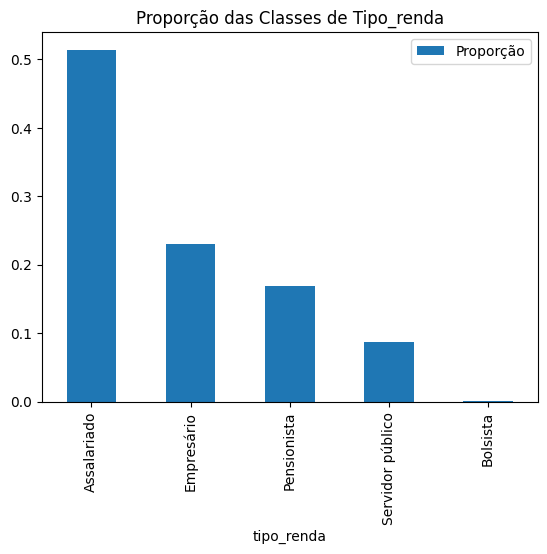

,Proporção
educacao,
Médio,0.675748
Superior completo,0.272400
Superior incompleto,0.039265
Fundamental,0.011502
Pós graduação,0.001085


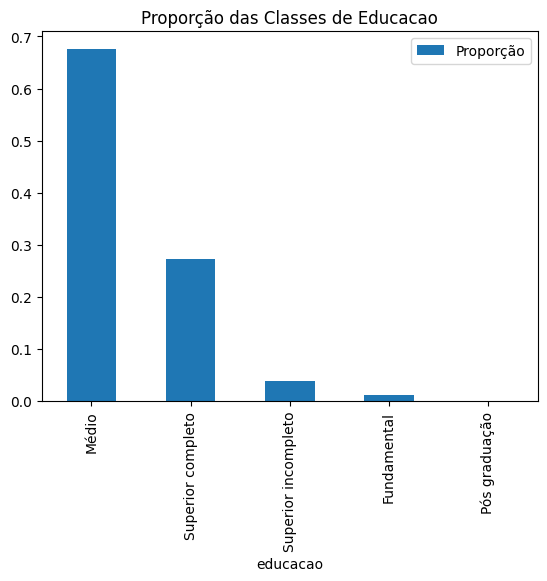

,Proporção
estado_civil,
Casado,0.701915
Solteiro,0.122035
União,0.076847
Separado,0.056980
Viúvo,0.042223


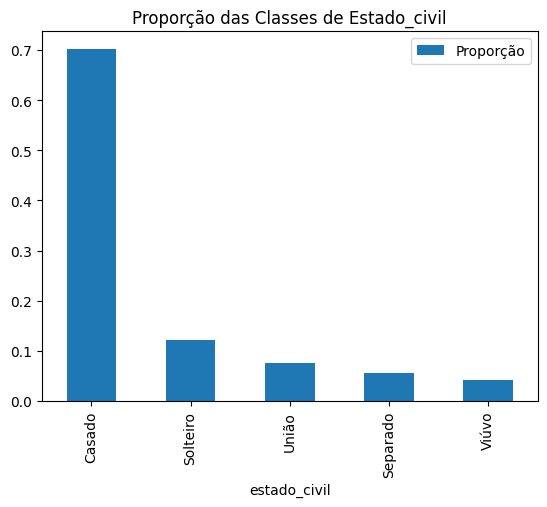

,Proporção
tipo_residencia,
Casa,0.898893
Com os pais,0.044550
Governamental,0.031237
Aluguel,0.013770
Estúdio,0.007160
Comunitário,0.004390


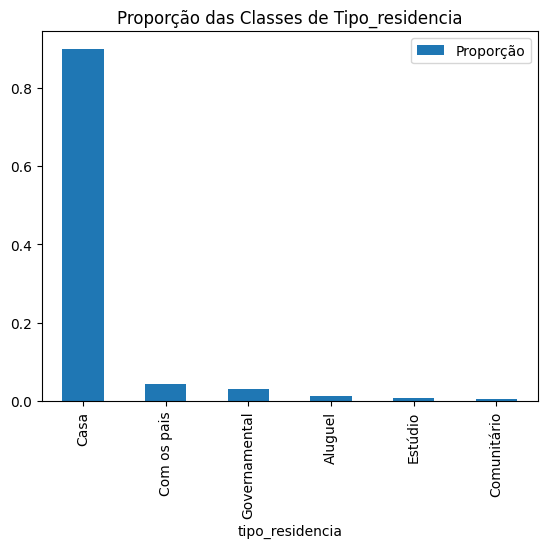

,idade
contagem,600000.000000
média,43.798530
desvio padrão,11.230659
min,22.000000
25%,34.000000
50%,43.000000
75%,53.000000
max,68.000000


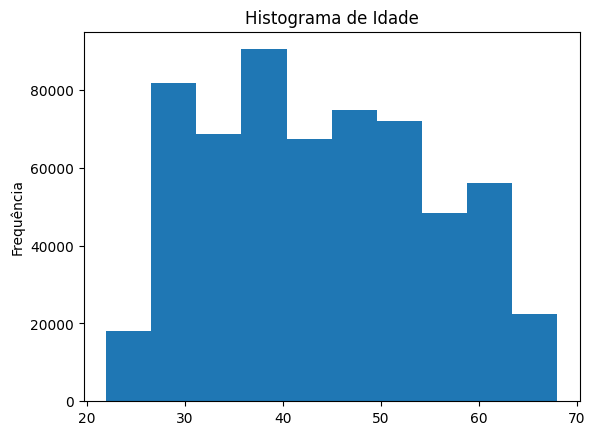

,tempo_emprego
contagem,499125.000000
média,7.747992
desvio padrão,6.688576
min,0.117808
25%,3.049315
50%,6.046575
75%,10.180822
max,42.906849


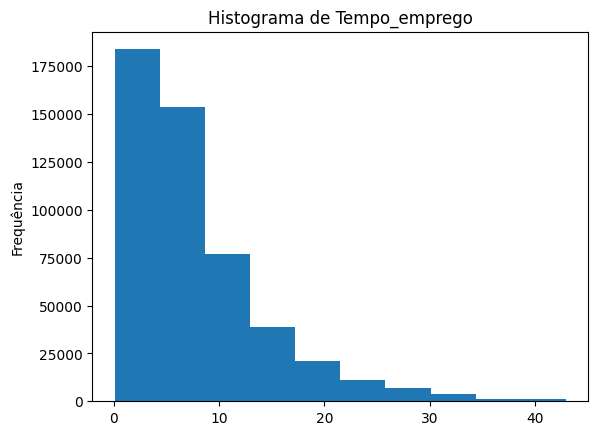

,qt_pessoas_residencia
contagem,600000.000000
média,2.212122
desvio padrão,0.903757
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,15.000000


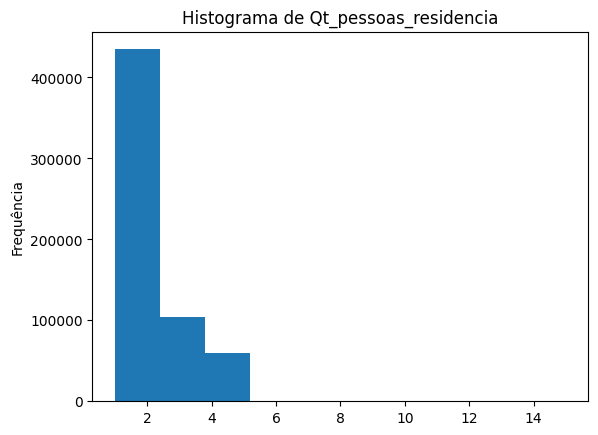

,renda
contagem,6.000000e+05
média,2.722284e+04
desvio padrão,8.737788e+04
min,1.618600e+02
25%,4.670600e+03
50%,9.887580e+03
75%,2.162887e+04
max,4.083986e+06


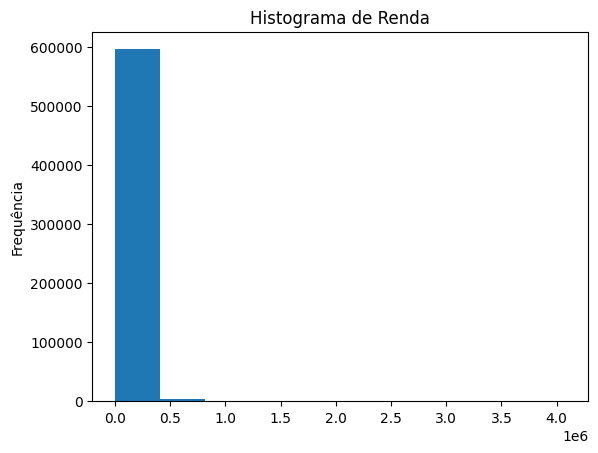

In [7]:
# Realizando análise univariada por cada variável na base de dados
for col in data:
    if metadata[metadata.index == col]['papel'].iloc[0] != 'independente':
        continue
    else:
        tipo =  metadata[metadata.index == col]['tipo_variavel'].iloc[0]
        analise_univariada(data[col], tipo)

## Descritiva bivariada

Faça uma análise descritiva bivariada de cada variável

In [8]:
# Definindo funções para conduzir análise bivariada (independente x dependente) por cada variável na base de dados
def categorizar_variavel(variavel: pd.Series) -> pd.Series:
    '''
    Função para categorizar uma variável contínua de forma a permitir a análise bivariada

    Parâmetros:
    - variavel: uma Series do Pandas, sendo essa a variável a ser categorizada
    '''
    labels = pd.qcut(variavel, 10, duplicates='drop')
    cat_variavel = pd.Series(labels, name=f'cat_{variavel.name}')
    return cat_variavel

def analise_bivariada(variavel: pd.Series, resposta: pd.Series) -> None:
    '''
    Função para conduzir uma análise bivariada com base nos cálculos de Weight of Evidence (WOE) e Information Value (IV) das variáveis.

    Parâmetros:
    - variavel: uma Series do Pandas, sendo essa a variável a ser estudada
    - resposta: uma Series do Pandas, sendo essa a variável resposta binária a se usar como base
    '''
    tab = pd.crosstab(variavel, resposta, margins=True)
    tab['Prop_nao_evento'] = tab[0] / tab[0].sum()
    tab['Prop_evento'] = tab[1] / tab[1].sum()

    epsilon = 1e-10
    tab['WOE'] = np.log((tab['Prop_nao_evento'] + epsilon) / (tab['Prop_evento'] + epsilon))
    tab['IV_parcial'] = (tab['Prop_nao_evento'] - tab['Prop_evento']) * tab['WOE']

    iv = tab['IV_parcial'].sum()

    display(tab)
    print(f'Information Value (IV) da variável {variavel.name}: {iv:.4%}')

    tab['WOE'].drop('All').plot(kind='barh', xlabel='Weight of Evidence', title=f'WOE por Classe da Variável {variavel.name.capitalize()}')
    plt.show()

def calcular_iv(variavel: pd.Series, resposta: pd.Series) -> float:
    '''
    Função para calcular o Information Value (IV) da variável.

    Parâmetros:
    - variavel: uma Series do Pandas, sendo essa a variável a ser estudada
    - resposta: uma Series do Pandas, sendo essa a variável resposta binária a se usar como base

    Retorna:
    - Information Value
    '''
    tab = pd.crosstab(variavel, resposta, margins=True)
    tab['Prop_nao_evento'] = tab[0] / tab[0].sum()
    tab['Prop_evento'] = tab[1] / tab[1].sum()

    epsilon = 1e-10
    tab['WOE'] = np.log((tab['Prop_nao_evento'] + epsilon) / (tab['Prop_evento'] + epsilon))
    tab['IV_parcial'] = (tab['Prop_nao_evento'] - tab['Prop_evento']) * tab['WOE']

    iv = tab['IV_parcial'].sum()
    return iv

def classificar_iv(iv: float) -> str:
    '''
    Função para classificar o IV de acordo com a classificação mais usada para contexto de credit score.

    Parâmetros:
    - iv: o valor de Information Value da variável

    Retorna:
    - Classificação de IV
    '''
    if iv < 0.02:
        return 'Inútil'
    elif 0.02 <= iv < 0.1:
        return 'Fraca'
    elif 0.1 <= iv < 0.3:
        return 'Média'
    elif 0.3 <= iv < 0.5:
        return 'Forte'
    return 'Sobreajuste'

Análise Bivariada da Variável Sexo


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
sexo,,,,,,,
F,378318,25487,403805,0.335771,0.347774,-0.035125,0.000422
M,185039,11156,196195,0.164229,0.152226,0.075898,0.000911
All,563357,36643,600000,0.500000,0.500000,0.000000,0.000000


Information Value (IV) da variável sexo: 0.1333%


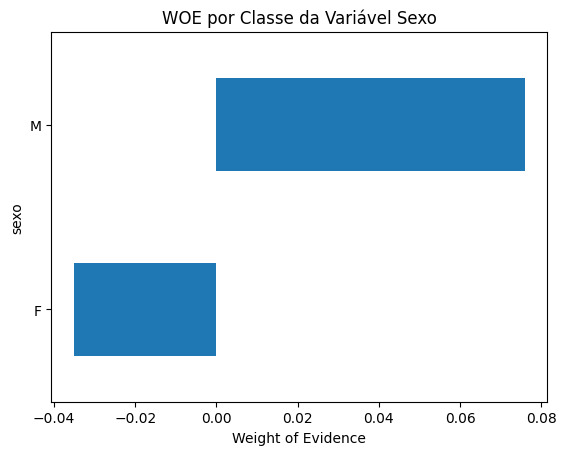

Análise Bivariada da Variável Posse_de_veiculo


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
posse_de_veiculo,,,,,,,
N,343778,22515,366293,0.305116,0.307221,-0.006877,0.000014
S,219579,14128,233707,0.194884,0.192779,0.010862,0.000023
All,563357,36643,600000,0.500000,0.500000,0.000000,0.000000


Information Value (IV) da variável posse_de_veiculo: 0.0037%


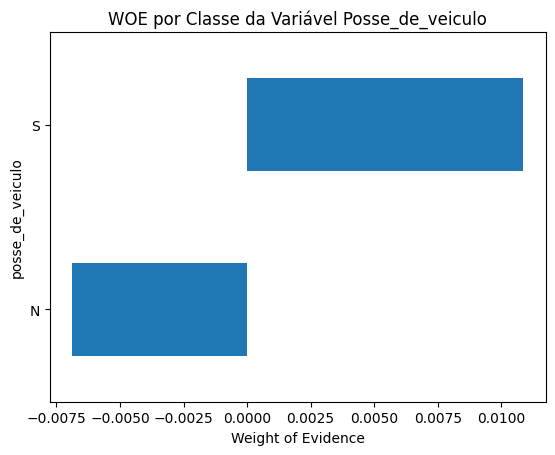

Análise Bivariada da Variável Posse_de_imovel


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
posse_de_imovel,,,,,,,
N,183305,13641,196946,0.16269,0.186134,-0.134620,0.003156
S,380052,23002,403054,0.33731,0.313866,0.072036,0.001689
All,563357,36643,600000,0.50000,0.500000,0.000000,0.000000


Information Value (IV) da variável posse_de_imovel: 0.4845%


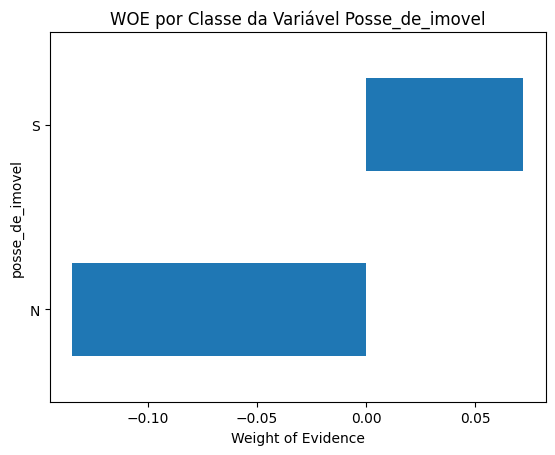

Análise Bivariada da Variável Qtd_filhos


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
cat_qtd_filhos,,,,,,,
"(-0.001, 1.0]",503676,32677,536353,0.447031,0.445883,0.002571,0.000003
"(1.0, 2.0]",52182,3421,55603,0.046313,0.046680,-0.007886,0.000003
"(2.0, 14.0]",7499,545,8044,0.006656,0.007437,-0.110952,0.000087
All,563357,36643,600000,0.500000,0.500000,0.000000,0.000000


Information Value (IV) da variável cat_qtd_filhos: 0.0092%


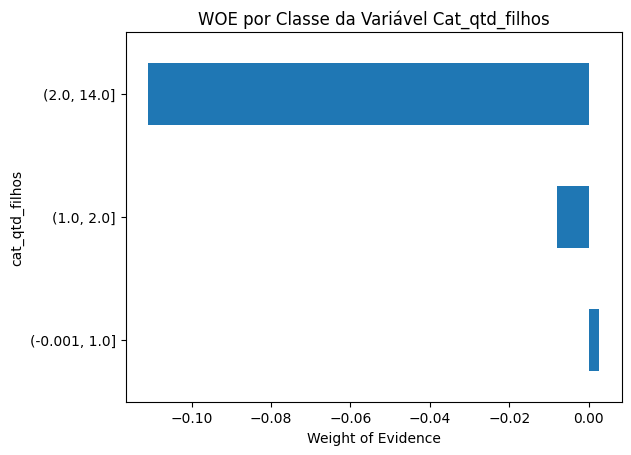

Análise Bivariada da Variável Tipo_renda


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
tipo_renda,,,,,,,
Assalariado,288865,19595,308460,0.256378,0.267377,-0.042006,0.000462
Bolsista,279,12,291,0.000248,0.000164,0.413614,0.000035
Empresário,129935,8206,138141,0.115322,0.111972,0.029478,0.000099
Pensionista,94627,6500,101127,0.083985,0.088694,-0.054550,0.000257
Servidor público,49651,2330,51981,0.044067,0.031793,0.326459,0.004007
All,563357,36643,600000,0.500000,0.500000,0.000000,0.000000


Information Value (IV) da variável tipo_renda: 0.4859%


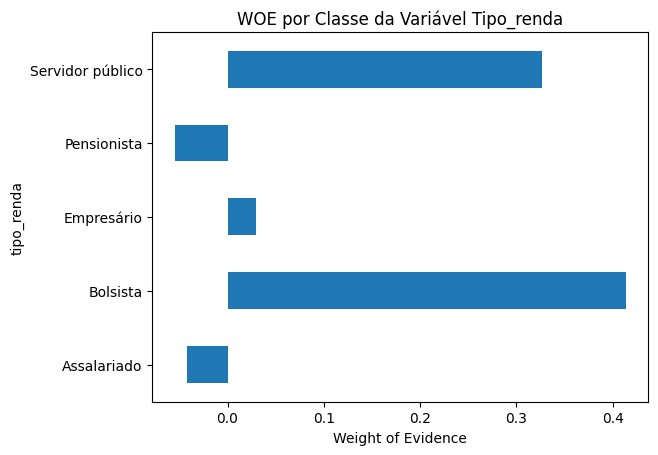

Análise Bivariada da Variável Educacao


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
educacao,,,,,,,
Fundamental,6420,481,6901,0.005698,0.006563,-0.141385,0.000122
Médio,379939,25510,405449,0.337210,0.348088,-0.031751,0.000345
Pós graduação,608,43,651,0.000540,0.000587,-0.083716,0.000004
Superior completo,154354,9086,163440,0.136995,0.123980,0.099823,0.001299
Superior incompleto,22036,1523,23559,0.019558,0.020782,-0.060696,0.000074
All,563357,36643,600000,0.500000,0.500000,0.000000,0.000000


Information Value (IV) da variável educacao: 0.1845%


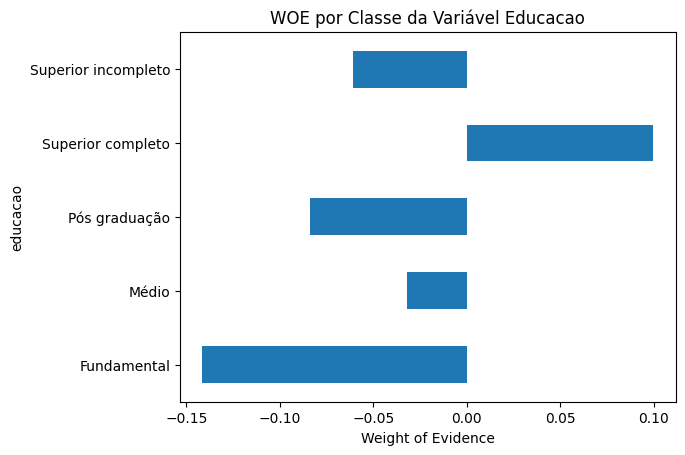

Análise Bivariada da Variável Estado_civil


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
estado_civil,,,,,,,
Casado,395880,25269,421149,0.351358,0.344800,0.018842,0.000124
Separado,31994,2194,34188,0.028396,0.029938,-0.052869,0.000082
Solteiro,68585,4636,73221,0.060872,0.063259,-0.038469,0.000092
União,43048,3060,46108,0.038207,0.041754,-0.088790,0.000315
Viúvo,23850,1484,25334,0.021168,0.020249,0.044352,0.000041
All,563357,36643,600000,0.500000,0.500000,0.000000,0.000000


Information Value (IV) da variável estado_civil: 0.0653%


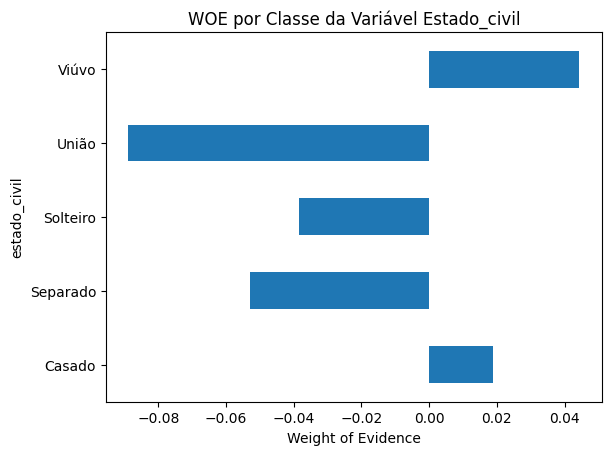

Análise Bivariada da Variável Tipo_residencia


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
tipo_residencia,,,,,,,
Aluguel,7666,596,8262,0.006804,0.008133,-0.178382,0.000237
Casa,506887,32449,539336,0.449881,0.442772,0.015927,0.000113
Com os pais,24733,1997,26730,0.021951,0.027249,-0.216199,0.001145
Comunitário,2449,185,2634,0.002174,0.002524,-0.149612,0.000052
Estúdio,4071,225,4296,0.003613,0.003070,0.162852,0.000088
Governamental,17551,1191,18742,0.015577,0.016251,-0.042373,0.000029
All,563357,36643,600000,0.500000,0.500000,0.000000,0.000000


Information Value (IV) da variável tipo_residencia: 0.1665%


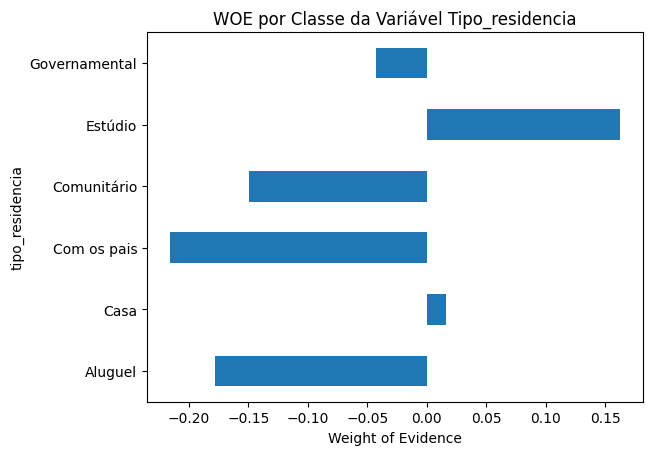

Análise Bivariada da Variável Idade


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
cat_idade,,,,,,,
"(21.999, 29.0]",61628,5356,66984,0.054697,0.073084,-0.289792,0.005328
"(29.0, 33.0]",63496,4655,68151,0.056355,0.063518,-0.119656,0.000857
"(33.0, 36.0]",46010,3079,49089,0.040836,0.042013,-0.028437,0.000033
"(36.0, 40.0]",69989,4624,74613,0.062118,0.063095,-0.015613,0.000015
"(40.0, 43.0]",49264,2852,52116,0.043724,0.038916,0.116482,0.000560
"(43.0, 47.0]",59192,3618,62810,0.052535,0.049368,0.062174,0.000197
"(47.0, 51.0]",55222,2916,58138,0.049012,0.039789,0.208457,0.001922
"(51.0, 55.0]",49126,2696,51822,0.043601,0.036787,0.169928,0.001158
"(55.0, 60.0]",61785,3708,65493,0.054836,0.050596,0.080477,0.000341


Information Value (IV) da variável cat_idade: 1.0420%


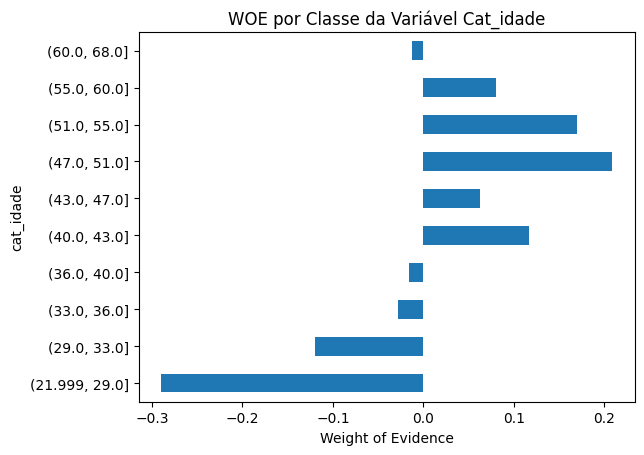

Análise Bivariada da Variável Tempo_emprego


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
cat_tempo_emprego,,,,,,,
"(0.11699999999999999, 1.195]",44598,5510,50108,0.047550,0.091331,-0.652711,0.028576
"(1.195, 2.364]",45006,4770,49776,0.047985,0.079065,-0.499386,0.015521
"(2.364, 3.63]",45691,4257,49948,0.048715,0.070562,-0.370499,0.008094
"(3.63, 4.693]",46190,3830,50020,0.049247,0.063484,-0.253937,0.003615
"(4.693, 6.047]",46750,3339,50089,0.049844,0.055346,-0.104692,0.000576
"(6.047, 7.458]",46944,2685,49629,0.050051,0.044505,0.117440,0.000651
"(7.458, 9.093]",47612,2315,49927,0.050763,0.038372,0.279840,0.003468
"(9.093, 11.726]",48265,1960,50225,0.051460,0.032488,0.459927,0.008726
"(11.726, 16.545]",48567,1057,49624,0.051782,0.017520,1.083674,0.037128


Information Value (IV) da variável cat_tempo_emprego: 19.5608%


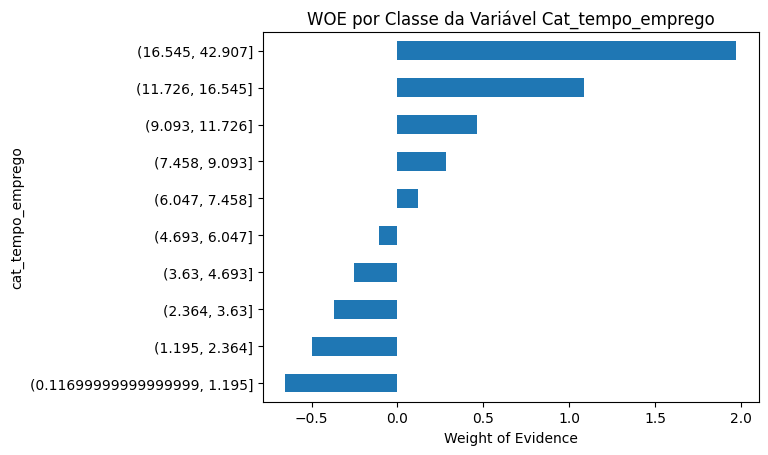

Análise Bivariada da Variável Qt_pessoas_residencia


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
cat_qt_pessoas_residencia,,,,,,,
"(0.999, 2.0]",408788,26050,434838,0.362814,0.355457,0.020488,1.507418e-04
"(2.0, 3.0]",97323,6803,104126,0.086378,0.092828,-0.072019,4.645519e-04
"(3.0, 4.0]",50051,3263,53314,0.044422,0.044524,-0.002296,2.343734e-07
"(4.0, 15.0]",7195,527,7722,0.006386,0.007191,-0.118750,9.561501e-05
All,563357,36643,600000,0.500000,0.500000,0.000000,0.000000e+00


Information Value (IV) da variável cat_qt_pessoas_residencia: 0.0711%


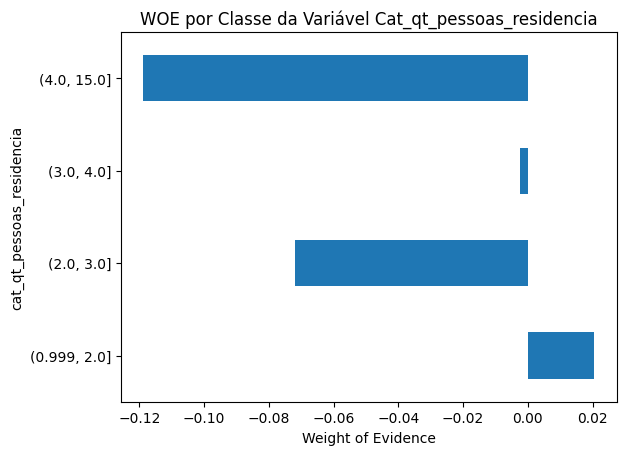

Análise Bivariada da Variável Renda


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
cat_renda,,,,,,,
"(161.859, 2450.919]",46939,13061,60000,0.041660,0.178220,-1.453473,0.198486
"(2450.919, 3905.11]",53265,6738,60003,0.047275,0.091941,-0.665175,0.029711
"(3905.11, 5513.49]",55227,4780,60007,0.049016,0.065224,-0.285680,0.004630
"(5513.49, 7430.69]",56458,3533,59991,0.050109,0.048208,0.038659,0.000073
"(7430.69, 9887.58]",57236,2764,60000,0.050799,0.037715,0.297813,0.003897
"(9887.58, 13152.38]",57901,2103,60004,0.051389,0.028696,0.582679,0.013223
"(13152.38, 18064.01]",58428,1570,59998,0.051857,0.021423,0.884028,0.026905
"(18064.01, 26666.57]",58888,1114,60002,0.052265,0.015201,1.234989,0.045774
"(26666.57, 49048.516]",59274,721,59995,0.052608,0.009838,1.676596,0.071707


Information Value (IV) da variável cat_renda: 52.8433%


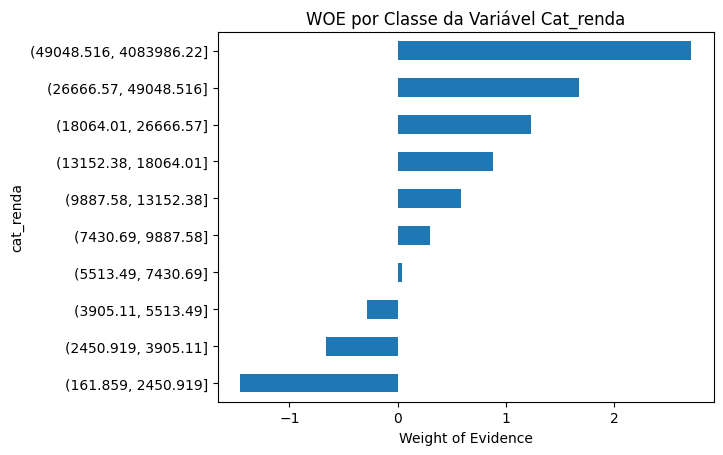

In [9]:
# Conduzindo análise bivariada
for col in data.drop(['data_ref', 'index', 'mau'], axis=1):
    print(f'Análise Bivariada da Variável {col.capitalize()}')
    if metadata.loc[col, 'tipo_variavel'] == 'contínua':
        analise_bivariada(categorizar_variavel(data[col]), data['mau'])
    else:
        analise_bivariada(data[col], data['mau'])
    print('=' * 120)

In [10]:
# Calculando e salvando Information Value e classificação nos metadados
metadata['IV'] = 0.0
metadata['classificação_IV'] = ''

for indx in metadata.index.drop(['data_ref', 'index', 'mau']):
    iv = calcular_iv(data[indx], data['mau'])
    metadata.loc[indx, 'IV'] = iv
    metadata.loc[indx, 'classificação_IV'] = classificar_iv(iv)

metadata

,dtype,num_missings,num_classes,tipo_variavel,papel,IV,classificação_IV
data_ref,datetime64[ns],0,12,discreta,não usar,0.000000,
index,int64,0,16650,contínua,não usar,0.000000,
sexo,object,0,2,discreta,independente,0.001333,Inútil
posse_de_veiculo,object,0,2,discreta,independente,0.000037,Inútil
posse_de_imovel,object,0,2,discreta,independente,0.004845,Inútil
qtd_filhos,int64,0,8,contínua,independente,0.000844,Inútil
tipo_renda,object,0,5,discreta,independente,0.004859,Inútil
educacao,object,0,5,discreta,independente,0.001845,Inútil
estado_civil,object,0,5,discreta,independente,0.000653,Inútil
tipo_residencia,object,0,6,discreta,independente,0.001665,Inútil


Conforme podemos observar na base, todas as variáveis independentes apresentam problemas para serem usadas na construção do modelo, portanto, vamos transforma-las e balancear a base de dados para a construção do modelo.

## Desenvolvimento do modelo

Desenvolva um modelo de *credit scoring* através de uma regressão logística.

- Trate valores missings e outliers
- Trate 'zeros estruturais'
- Faça agrupamentos de categorias conforme vimos em aula
- Proponha uma equação preditiva para 'mau'
- Caso hajam categorias não significantes, justifique

In [11]:
# Substituindo dados missings de Tempo Emprego com média
data.fillna(value=data['tempo_emprego'].mean(), inplace=True)
data.isna().sum()

data_ref                 0
index                    0
sexo                     0
posse_de_veiculo         0
posse_de_imovel          0
qtd_filhos               0
tipo_renda               0
educacao                 0
estado_civil             0
tipo_residencia          0
idade                    0
tempo_emprego            0
qt_pessoas_residencia    0
renda                    0
mau                      0
dtype: int64

In [12]:
# Fazendo downsampling para balancear a base de dados entre bons e maus pagadores (50/50)
events_data = data[data['mau'] == True]
not_events_data = data[data['mau'] == False]

sample_not_events = not_events_data.sample(n=len(events_data), random_state=412)

data_balanced = pd.concat([events_data, sample_not_events]).sample(frac=1, random_state=412).reset_index(drop=True)

data_balanced.mau.value_counts(normalize=True)

mau
False    0.5
True     0.5
Name: proportion, dtype: float64

In [14]:
# Conduzindo uma análise univariada comparativa
for col in data_balanced:
    if metadata[metadata.index == col]['papel'].iloc[0] != 'independente':
        continue
    else:
        print('Análise Univariada Comparativa da Variável {}'.format(col.capitalize()))
        if metadata[metadata.index == col]['tipo_variavel'].iloc[0] == 'discreta':
            tab_1 = pd.DataFrame(data[col].value_counts(normalize=True)).rename({'proportion': 'Proporção Original'}, axis=1)
            tab_2 = pd.DataFrame(data_balanced[col].value_counts(normalize=True)).rename({'proportion': 'Proporção Balanceada'}, axis=1)
            display(pd.concat([tab_1, tab_2], axis=1))
            print('='*100)
        else:
            des_1 = pd.DataFrame(data[col].describe()).rename({'count': 'contagem', 'mean': 'média', 'std': 'desvio padrão'})
            des_2 = pd.DataFrame(data_balanced[col].describe()).rename({'count': 'contagem', 'mean': 'média', 'std': 'desvio padrão'})
            display(pd.concat([des_1, des_2], axis=1))
            print('='*50)

Análise Univariada Comparativa da Variável Sexo


,Proporção Original,Proporção Balanceada
sexo,,
F,0.673008,0.685124
M,0.326992,0.314876


Análise Univariada Comparativa da Variável Posse_de_veiculo


,Proporção Original,Proporção Balanceada
posse_de_veiculo,,
N,0.610488,0.611822
S,0.389512,0.388178


Análise Univariada Comparativa da Variável Posse_de_imovel


...

,tempo_emprego,tempo_emprego
contagem,600000.000000,73286.000000
média,7.747992,6.580919
desvio padrão,6.100461,5.316158
min,0.117808,0.117808
25%,3.635616,2.800000
50%,7.473973,6.068493
75%,9.069863,7.747992
max,42.906849,42.906849


Análise Univariada Comparativa da Variável Qt_pessoas_residencia


,qt_pessoas_residencia,qt_pessoas_residencia
contagem,600000.000000,73286.000000
média,2.212122,2.220683
desvio padrão,0.903757,0.913925
min,1.000000,1.000000
25%,2.000000,2.000000
50%,2.000000,2.000000
75%,3.000000,3.000000
max,15.000000,15.000000


Análise Univariada Comparativa da Variável Renda


,renda,renda
contagem,6.000000e+05,7.328600e+04
média,2.722284e+04,1.788390e+04
desvio padrão,8.737788e+04,7.089482e+04
min,1.618600e+02,1.618600e+02
25%,4.670600e+03,2.748120e+03
50%,9.887580e+03,5.992000e+03
75%,2.162887e+04,1.367219e+04
max,4.083986e+06,3.728517e+06


In [15]:
# Calculando novos Information Value
metadata['IV_balanceada'] = 0.0
metadata['classificação_IV_balanceada'] = ''

for indx in metadata.index.drop(['data_ref', 'index', 'mau']):
    iv = calcular_iv(data_balanced[indx], data_balanced['mau'])
    metadata.loc[indx, 'IV_balanceada'] = iv
    metadata.loc[indx, 'classificação_IV_balanceada'] = classificar_iv(iv)

metadata

,dtype,num_missings,num_classes,tipo_variavel,papel,IV,classificação_IV,IV_balanceada,classificação_IV_balanceada
data_ref,datetime64[ns],0,12,discreta,não usar,0.000000,,0.000000,
index,int64,0,16650,contínua,não usar,0.000000,,0.000000,
sexo,object,0,2,discreta,independente,0.001333,Inútil,0.001008,Inútil
posse_de_veiculo,object,0,2,discreta,independente,0.000037,Inútil,0.000058,Inútil
posse_de_imovel,object,0,2,discreta,independente,0.004845,Inútil,0.005112,Inútil
qtd_filhos,int64,0,8,contínua,independente,0.000844,Inútil,0.001106,Inútil
tipo_renda,object,0,5,discreta,independente,0.004859,Inútil,0.005372,Inútil
educacao,object,0,5,discreta,independente,0.001845,Inútil,0.001389,Inútil
estado_civil,object,0,5,discreta,independente,0.000653,Inútil,0.000933,Inútil
tipo_residencia,object,0,6,discreta,independente,0.001665,Inútil,0.001800,Inútil


Conforme observamos, o **downsampling** para balancear a variável resposta não alterou a situação dos dados, apenas reduziu a quantidade de linhas, o que pode resultar na redução do custo computacional do modelo. Como as presentes variáveis não apresentam valor em sua forma atual, vamos tratá-las das seguintes formas: as variáveis discretas serão tratadas com  **One-hot encoding**, já as variáveis contínuas serão padronizadas e todas as variáveis serão combinadas com **Análise de Componentes Principais**.

In [16]:
# Tratamento com one-hot encoding
for col in data_balanced.drop(['data_ref', 'index', 'mau'], axis=1):
    if metadata.loc[col, 'tipo_variavel'] == 'discreta':
        print(f'Cálculo de IV das Variáveis Criadas: {col}')
        dummies = pd.get_dummies(data_balanced[col], prefix=col)
        data_balanced = pd.concat([data_balanced.drop(col, axis=1), dummies], axis=1)
        iv = [calcular_iv(dummies[column], data_balanced['mau']) for column in dummies]
        for indx in range(len(iv)):
            print(f'IV de {dummies.columns[indx]}: {iv[0]:.4%} - {classificar_iv(iv[indx])}')
        print('='*100)

Cálculo de IV das Variáveis Criadas: sexo
IV de sexo_F: 0.1008% - Inútil
IV de sexo_M: 0.1008% - Inútil
Cálculo de IV das Variáveis Criadas: posse_de_veiculo
IV de posse_de_veiculo_N: 0.0058% - Inútil
IV de posse_de_veiculo_S: 0.0058% - Inútil
Cálculo de IV das Variáveis Criadas: posse_de_imovel
IV de posse_de_imovel_N: 0.5112% - Inútil
IV de posse_de_imovel_S: 0.5112% - Inútil
Cálculo de IV das Variáveis Criadas: tipo_renda
IV de tipo_renda_Assalariado: 0.1056% - Inútil
IV de tipo_renda_Bolsista: 0.1056% - Inútil
IV de tipo_renda_Empresário: 0.1056% - Inútil
IV de tipo_renda_Pensionista: 0.1056% - Inútil
IV de tipo_renda_Servidor público: 0.1056% - Inútil
Cálculo de IV das Variáveis Criadas: educacao
IV de educacao_Fundamental: 0.0061% - Inútil
IV de educacao_Médio: 0.0061% - Inútil
IV de educacao_Pós graduação: 0.0061% - Inútil
IV de educacao_Superior completo: 0.0061% - Inútil
IV de educacao_Superior incompleto: 0.0061% - Inútil
Cálculo de IV das Variáveis Criadas: estado_civil
IV d

In [17]:
# Eliminando variáveis que não serão usadas no modelo
data_balanced.drop(['data_ref', 'index'], axis=1, inplace=True)

# Transformando tipos de dados
data_balanced[data_balanced.columns[5:]] = data_balanced[data_balanced.columns[5:]].astype(np.int64)

# Visualizando
data_balanced.head(5)

,qtd_filhos,idade,tempo_emprego,qt_pessoas_residencia,renda,mau,sexo_F,sexo_M,posse_de_veiculo_N,posse_de_veiculo_S,...,estado_civil_Separado,estado_civil_Solteiro,estado_civil_União,estado_civil_Viúvo,tipo_residencia_Aluguel,tipo_residencia_Casa,tipo_residencia_Com os pais,tipo_residencia_Comunitário,tipo_residencia_Estúdio,tipo_residencia_Governamental
0,0,58,10.936986,2.0,16050.73,0,1,0,1,0,...,0,0,0,0,0,1,0,0,0,0
1,0,33,7.128767,2.0,11436.10,1,0,1,0,1,...,0,0,0,0,0,0,1,0,0,0
2,2,36,6.786301,4.0,18459.96,1,0,1,0,1,...,0,0,0,0,0,1,0,0,0,0
3,0,64,7.747992,2.0,1686.53,0,1,0,0,1,...,0,0,0,0,0,1,0,0,0,0
4,0,59,6.646575,2.0,1430.03,1,0,1,0,1,...,0,0,0,0,0,1,0,0,0,0


In [18]:
# Criando objetos para padronizar variáveis contínuas 
scaler = StandardScaler()

# Criando dataframe apenas com variáveis contínuas
data_sub = data_balanced[list(metadata[metadata['tipo_variavel'] == 'contínua'].index.drop('index'))]
numeric_features = data_sub.columns

# Transformando variáveis com padronização 
data_sub = scaler.fit_transform(data_sub)

# Visualizando resultado
data_sub = pd.DataFrame(data_sub, columns=numeric_features)
data_sub.head(5)

,qtd_filhos,idade,tempo_emprego,qt_pessoas_residencia,renda
0,-0.591779,1.290792,0.819407,-0.241469,-0.025858
1,-0.591779,-0.902838,0.103054,-0.241469,-0.090949
2,2.077500,-0.639603,0.038634,1.946910,0.008126
3,-0.591779,1.817263,0.219535,-0.241469,-0.228472
4,-0.591779,1.378537,0.012350,-0.241469,-0.232090


In [19]:
# Calculando Information Value das variáveis transformadas
for col in data_sub:
    iv = calcular_iv(data_sub[col], data_balanced['mau'])
    print(f'IV da variável {col} padronizada igual a : {iv} - {classificar_iv(iv)}')

IV da variável qtd_filhos padronizada igual a : 0.0011058062544143429 - Inútil
IV da variável idade padronizada igual a : 0.015309397332163363 - Inútil
IV da variável tempo_emprego padronizada igual a : 0.6247346806838664 - Sobreajuste
IV da variável qt_pessoas_residencia padronizada igual a : 0.0018029491625195487 - Inútil
IV da variável renda padronizada igual a : 9.095290966072339 - Sobreajuste


In [20]:
# Comparando com IV balanceado
metadata[metadata.index.isin(numeric_features)]

,dtype,num_missings,num_classes,tipo_variavel,papel,IV,classificação_IV,IV_balanceada,classificação_IV_balanceada
qtd_filhos,int64,0,8,contínua,independente,0.000844,Inútil,0.001106,Inútil
idade,int64,0,47,contínua,independente,0.012831,Inútil,0.015309,Inútil
tempo_emprego,float64,100875,3004,contínua,independente,0.666583,Sobreajuste,0.624735,Sobreajuste
qt_pessoas_residencia,float64,0,9,contínua,independente,0.001608,Inútil,0.001803,Inútil
renda,float64,0,112472,contínua,independente,4.899994,Sobreajuste,9.095291,Sobreajuste


In [21]:
# Substituindo variáveis na base de dados
data_balanced = pd.concat([data_balanced.drop(numeric_features, axis=1), data_sub], axis=1)
data_balanced.head(5)

,mau,sexo_F,sexo_M,posse_de_veiculo_N,posse_de_veiculo_S,posse_de_imovel_N,posse_de_imovel_S,tipo_renda_Assalariado,tipo_renda_Bolsista,tipo_renda_Empresário,...,tipo_residencia_Casa,tipo_residencia_Com os pais,tipo_residencia_Comunitário,tipo_residencia_Estúdio,tipo_residencia_Governamental,qtd_filhos,idade,tempo_emprego,qt_pessoas_residencia,renda
0,0,1,0,1,0,1,0,1,0,0,...,1,0,0,0,0,-0.591779,1.290792,0.819407,-0.241469,-0.025858
1,1,0,1,0,1,0,1,1,0,0,...,0,1,0,0,0,-0.591779,-0.902838,0.103054,-0.241469,-0.090949
2,1,0,1,0,1,0,1,1,0,0,...,1,0,0,0,0,2.077500,-0.639603,0.038634,1.946910,0.008126
3,0,1,0,0,1,0,1,0,0,0,...,1,0,0,0,0,-0.591779,1.817263,0.219535,-0.241469,-0.228472
4,1,0,1,0,1,0,1,1,0,0,...,1,0,0,0,0,-0.591779,1.378537,0.012350,-0.241469,-0.232090


In [22]:
# Separando as variáveis independentes da variável dependente
X = data_balanced.drop('mau', axis=1)
y = data_balanced['mau']

# Separando dados em bases de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=412)

# Visualizando
print(f'Tamanho da base de treino: {X_train.shape}\nTamanho da base de teste: {X_test.shape}')

Tamanho da base de treino: (51300, 32)
Tamanho da base de teste: (21986, 32)


In [23]:
# Criando objetos para combinar variáveis
pca = PCA(n_components=16)

# Treinando objeto com as variáveis da base 
principal_components_train = pca.fit(X_train)
principal_components_test = pca.fit(X_test)

# Visualizando variância capturada pela combinação linear na base
print('Variância Explicada na Base de Treino:')
print(principal_components_train.explained_variance_ratio_)
print('Variância Explicada na Base de Teste:')
print(principal_components_test.explained_variance_ratio_)

Variância Explicada na Base de Treino:
[0.28086963 0.17524163 0.11077691 0.07262906 0.06063162 0.05289359
 0.05016889 0.03796922 0.0371044  0.03406637 0.01569482 0.01457135
 0.01393631 0.01018563 0.00934494 0.00719633]
Variância Explicada na Base de Teste:
[0.28086963 0.17524163 0.11077691 0.07262906 0.06063162 0.05289359
 0.05016889 0.03796922 0.0371044  0.03406637 0.01569482 0.01457135
 0.01393631 0.01018563 0.00934494 0.00719633]


In [24]:
# Transformando base de treinamento e teste
X_train = principal_components_train.transform(X_train)
X_test = principal_components_test.transform(X_test)

# Transformando em dataframe
X_train = pd.DataFrame(X_train, columns=[f'PC_{num+1}' for num in range(X_train.shape[1])])
X_test = pd.DataFrame(X_test, columns=[f'PC_{num+1}' for num in range(X_test.shape[1])])

# Visualizando
X_train.head(5)

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,PC_11,PC_12,PC_13,PC_14,PC_15,PC_16
0,-1.547687,0.423567,-1.445680,0.150899,0.410742,0.151256,-0.021820,0.071809,-0.404171,0.107705,0.287092,-0.177640,-0.033817,0.240422,0.064230,-0.031516
1,1.836208,-0.485307,0.685074,1.047680,-0.303629,0.409153,0.658725,-0.901829,-0.338696,0.251632,-0.086269,-0.317525,-0.109525,0.149132,0.108487,-0.174912
2,1.821592,-0.244626,0.892270,0.205943,0.043977,0.855750,0.455919,-0.683338,-0.055137,1.247842,-0.112345,-0.305438,-0.071600,0.119327,0.109146,-0.160684
3,-1.448097,-0.772909,0.279998,0.802512,0.704587,-0.671974,0.922891,0.203435,0.681189,0.325967,-0.419285,0.357947,-0.395345,0.088527,-0.436102,-0.052358
4,-0.142265,-0.533848,0.510276,-0.324752,-0.790657,0.831489,-0.581952,-0.077326,-0.366967,0.849661,-0.215391,-0.177710,-0.063164,-0.005171,0.002240,-0.049030


In [25]:
# Calculando Information Value das componentes principais
for col in X_train:
    iv = calcular_iv(X_train[col], data_balanced['mau'])
    print(f'IV da variável {col} padronizada igual a : {iv} - {classificar_iv(iv)}')

IV da variável PC_1 padronizada igual a : 9.466375172283133 - Sobreajuste
IV da variável PC_2 padronizada igual a : 9.465954378239772 - Sobreajuste
IV da variável PC_3 padronizada igual a : 9.466135550412552 - Sobreajuste
IV da variável PC_4 padronizada igual a : 9.466402210222633 - Sobreajuste
IV da variável PC_5 padronizada igual a : 9.466583382395413 - Sobreajuste
IV da variável PC_6 padronizada igual a : 9.466135550412552 - Sobreajuste
IV da variável PC_7 padronizada igual a : 9.466375172283133 - Sobreajuste
IV da variável PC_8 padronizada igual a : 9.466108512473054 - Sobreajuste
IV da variável PC_9 padronizada igual a : 9.466583382395413 - Sobreajuste
IV da variável PC_10 padronizada igual a : 9.466108512473056 - Sobreajuste
IV da variável PC_11 padronizada igual a : 9.46661042033491 - Sobreajuste
IV da variável PC_12 padronizada igual a : 9.466108512473056 - Sobreajuste
IV da variável PC_13 padronizada igual a : 9.466108512473056 - Sobreajuste
IV da variável PC_14 padronizada ig

In [26]:
# Criando o modelo
logistic = LogisticRegression(max_iter=35)

# Treinando o modelo
logistic.fit(X_train, y_train)

LogisticRegression(max_iter=35)

## Avaliação do modelo

Avalie o poder discriminante do modelo pelo menos avaliando acurácia, KS e Gini.

Avalie estas métricas nas bases de desenvolvimento e *out of time*.

                    Métricas do modelo na base de treino                   
Acurácia do modelo na base de treino: 68.19%
AUC do modelo na base de treino: 68.20%
Coeficiente de Gini do modelo na base de treino: 36.39%
KS do modelo na base de treino: 0.3884


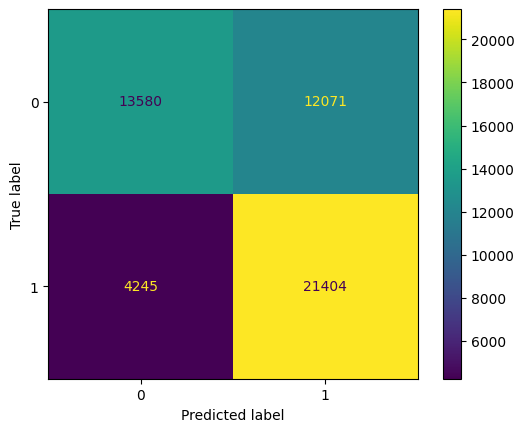

                    Métricas do modelo na base de teste                    
Acurácia do modelo na base de teste: 68.43%
AUC do modelo na base de teste: 68.42%
Coeficiente de Gini do modelo na base de teste: 36.85%
KS do modelo na base de teste: 0.3963


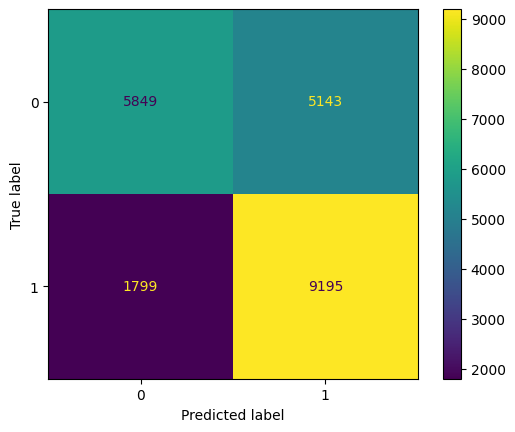

In [27]:
# Criando previsão de classes com a base de treino
y_pred_train = logistic.predict(X_train)

# Criando previsão de probabilidades com base de treino
y_probs_train = logistic.predict_proba(X_train)

# Calculando métricas na base de treinamento
acc_train = accuracy_score(y_train, y_pred_train)
auc_train = roc_auc_score(y_train, y_pred_train)
gini_train = 2 * auc_train - 1
fpr, tpr, _ = roc_curve(y_train, y_probs_train[:, 1])
ks_train = max(tpr - fpr)

# Criando previsão de classes com a base de teste
y_pred_test = logistic.predict(X_test)

# Criando previsão de probabilidades com base de teste
y_probs_test = logistic.predict_proba(X_test)

# Calculando métricas na base de teste
acc_test = accuracy_score(y_test, y_pred_test)
auc_test = roc_auc_score(y_test, y_pred_test)
gini_test = 2 * auc_test - 1
fpr, tpr, _ = roc_curve(y_test, y_probs_test[:, 1])
ks_test = max(tpr - fpr)

# Visualizando métricas na base de treino
print('='*75)
print('Métricas do modelo na base de treino'.center(75))
print('='*75)
print(f'Acurácia do modelo na base de treino: {acc_train:.2%}')
print(f'AUC do modelo na base de treino: {auc_train:.2%}')
print(f'Coeficiente de Gini do modelo na base de treino: {gini_train:.2%}')
print(f'KS do modelo na base de treino: {ks_train:.4f}')

# Criando e plotando matrix de confusão na base de treino
cm = confusion_matrix(y_train, y_pred_train)
cm_disp = ConfusionMatrixDisplay(cm)
cm_disp.plot()
plt.show()

# Visualizando métricas na base de teste
print('='*75)
print('Métricas do modelo na base de teste'.center(75))
print('='*75)
print(f'Acurácia do modelo na base de teste: {acc_test:.2%}')
print(f'AUC do modelo na base de teste: {auc_test:.2%}')
print(f'Coeficiente de Gini do modelo na base de teste: {gini_test:.2%}')
print(f'KS do modelo na base de teste: {ks_test:.4f}')

# Criando e plotando matrix de confusão na base de teste
cm = confusion_matrix(y_test, y_pred_test)
cm_disp = ConfusionMatrixDisplay(cm)
cm_disp.plot()
plt.show()

In [28]:
# Avaliando o modelo com a base de validação (OOT)

# Removendo valores missings
data_unseen.fillna(data_unseen['tempo_emprego'].mean(), inplace=True)

# Separando base de dados
X_unseen = data_unseen.drop(['data_ref', 'index', 'mau'], axis=1)
y_unseen = data_unseen['mau']

# One-hot encoding das variáveis discretas
for col in X_unseen:
    if metadata.loc[col, 'tipo_variavel'] == 'discreta':
        dummies = pd.get_dummies(X_unseen[col], prefix=col)
        X_unseen = pd.concat([X_unseen.drop(col, axis=1), dummies.astype(np.int64)], axis=1)

# Padronizando variáveis contínuas
X_unseen[numeric_features] = scaler.fit_transform(X_unseen[numeric_features])

# Combinando variaveis
pc = pca.fit(X_unseen)
X_unseen = pc.transform(X_unseen)
X_unseen = pd.DataFrame(X_unseen, columns=[f'PC_{num+1}' for num in range(X_unseen.shape[1])])

# Calculando acurácia
y_pred = logistic.predict(X_unseen)
print(f'Acurácia do modelo final igual a {accuracy_score(y_unseen, y_pred):.2%}')

Acurácia do modelo final igual a 53.36%


# a - Criar um pipeline utilizando o sklearn pipeline para o preprocessamento 

## Pré processamento

### Substituição de nulos (nans)

Existe nulos na base? é dado numérico ou categórico? qual o valor de substituição? média? valor mais frequente? etc

In [29]:
# Verificando missings na base original
df.isna().sum()

data_ref                      0
index                         0
sexo                          0
posse_de_veiculo              0
posse_de_imovel               0
qtd_filhos                    0
tipo_renda                    0
educacao                      0
estado_civil                  0
tipo_residencia               0
idade                         0
tempo_emprego            125957
qt_pessoas_residencia         0
renda                         0
mau                           0
dtype: int64

Conforme podemos observar, a coluna **tempo_emprego** é a única na base que contém valores missings, nossa abordagem foi substituir esses valores pela média dos valores da coluna.

In [30]:
# Criando nova base para manipulação dos dados usando 20% da base original já tratada no exercicio anterior
sample_data = data.sample(frac=.2, random_state=412).drop(['data_ref', 'index'], axis=1)

sample_data.isna().sum()

sexo                     0
posse_de_veiculo         0
posse_de_imovel          0
qtd_filhos               0
tipo_renda               0
educacao                 0
estado_civil             0
tipo_residencia          0
idade                    0
tempo_emprego            0
qt_pessoas_residencia    0
renda                    0
mau                      0
dtype: int64

### Remoção de outliers

Como identificar outlier? Substituir o outlier por algum valor? Remover a linha?

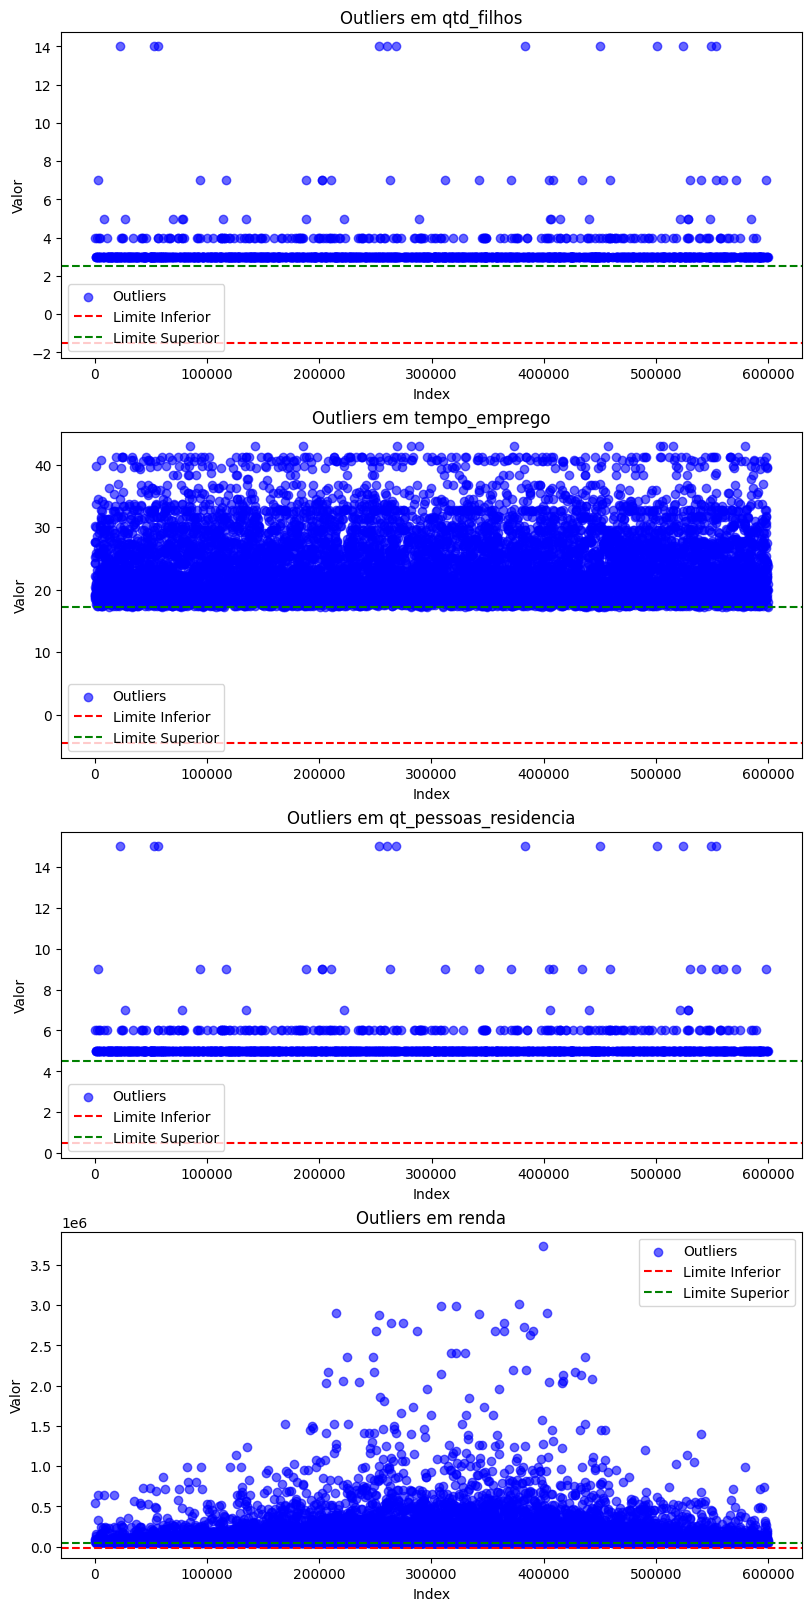

In [31]:
# Definindo função para visualizar outliers nos dados
def visualizar_outliers(X: pd.DataFrame, threshold: float=1.5):
    '''
    Função para visualizar outliers dos dados em um gráfico de dispersão

    Parâmetros:
    - X: dataframe do Pandas com as variáveis independentes
    - threshold: valor limiar usado para calcular os intervalos dos limites superior e inferior
    '''
    Q1 = X.quantile(0.25)
    Q3 = X.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    
    outlier_cols = {col: X[(X[col] < lower_bound[col]) | (X[col] > upper_bound[col])][col] 
                    for col in X.columns if ((X[col] < lower_bound[col]) | (X[col] > upper_bound[col])).any()}
    
    num_cols = len(outlier_cols)
    if num_cols > 0:
        fig, axes = plt.subplots(num_cols, 1, figsize=(8, 4 * num_cols), constrained_layout=True)
    
        if num_cols == 1:
            axes = [axes] 
    
        for ax, (col, outliers) in zip(axes, outlier_cols.items()):
            ax.scatter(outliers.index, outliers, color='b', label='Outliers', alpha=0.6)
            ax.axhline(y=lower_bound[col], color='r', linestyle='dashed', label='Limite Inferior')
            ax.axhline(y=upper_bound[col], color='g', linestyle='dashed', label='Limite Superior')
            
            ax.set_title(f'Outliers em {col}')
            ax.set_xlabel('Index')
            ax.set_ylabel('Valor')
            ax.legend()
        
        plt.show()
    else:
        print('Nenhum outliers detectado')

# Criando subconjunto dos dados contendo apenas as variáveis independentes contínuas
X_numeric = sample_data[numeric_features]

# Visualizando outliers
visualizar_outliers(X_numeric)

Como podemos observar, as variáveis apresentam um número exarcebado de outliers, o que pode prejudicar o desempenho do modelo, portanto, vamos substituir todos os valores de outliers pela média das respectivas colunas e veremos os gráficos dos outliers novamente.

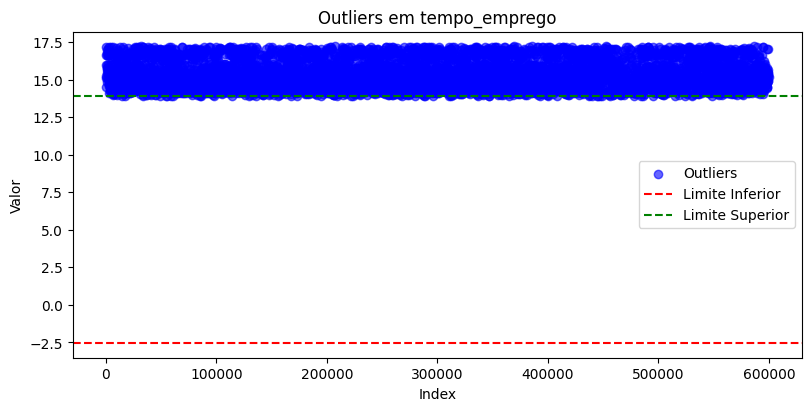

In [32]:
# Calculando novos limites
Q1 = X_numeric.quantile(0.25)
Q3 = X_numeric.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Substituindo valores que ultrapassam limites pela média da coluna
X_masked = X_numeric.mask((X_numeric < lower_bound) | (X_numeric > upper_bound), X_numeric.mean(), axis=1)

# Visualizando outliers
visualizar_outliers(X_masked)

In [33]:
# Concatenando o dataframe criado com a amostra
X_masked = pd.concat([X_masked, sample_data.drop(columns=X_masked.columns)], axis=1)
X_masked.drop('mau', axis=1, inplace=True)
X_masked.head(5)

,qtd_filhos,idade,tempo_emprego,qt_pessoas_residencia,renda,sexo,posse_de_veiculo,posse_de_imovel,tipo_renda,educacao,estado_civil,tipo_residencia
560972,2.0,38,2.810959,4.0,1548.340000,M,N,S,Assalariado,Médio,Casado,Casa
159537,0.0,38,6.216438,2.0,10820.650000,F,S,S,Empresário,Médio,Casado,Casa
54637,0.0,56,7.737070,1.0,26838.094494,F,N,N,Assalariado,Médio,Solteiro,Casa
591304,0.0,59,7.747992,2.0,2635.990000,F,S,N,Pensionista,Médio,União,Casa
131575,0.0,60,7.747992,1.0,2515.390000,F,N,N,Pensionista,Médio,Viúvo,Casa


In [34]:
# Padronizando variáveis contínuas
scaler_numeric = StandardScaler()
scaler_numeric.fit(X_masked[numeric_features])

StandardScaler()

In [35]:
# Aplicando a padronização nas variáveis
X_masked[numeric_features] = scaler_numeric.transform(X_masked[numeric_features])

# Visualizando
X_masked.head(5)                                                

,qtd_filhos,idade,tempo_emprego,qt_pessoas_residencia,renda,sexo,posse_de_veiculo,posse_de_imovel,tipo_renda,educacao,estado_civil,tipo_residencia
560972,2.476445,-0.516878,-1.007728,2.218739,-1.115514,M,N,S,Assalariado,Médio,Casado,Casa
159537,-0.607688,-0.516878,-0.083236,-0.210328,-0.245440,F,S,S,Empresário,Médio,Casado,Casa
54637,-0.607688,1.084583,0.329573,-1.424861,1.257569,F,N,N,Assalariado,Médio,Solteiro,Casa
591304,-0.607688,1.351493,0.332538,-0.210328,-1.013453,F,S,N,Pensionista,Médio,União,Casa
131575,-0.607688,1.440463,0.332538,-1.424861,-1.024770,F,N,N,Pensionista,Médio,Viúvo,Casa


### Criação de dummies

Aplicar o get_dummies() ou onehotencoder() para transformar colunas catégoricas do dataframe em colunas de 0 e 1. 
- sexo
- posse_de_veiculo
- posse_de_imovel
- tipo_renda
- educacao
- estado_civil
- tipo_residencia

In [36]:
# Selecionado as variáveis discretas/categóricas da base
categorical_features = sample_data.drop(['mau'], axis=1).columns[~(sample_data.drop(['mau'], axis=1).columns.isin(numeric_features))]

# Aplicando one-hot encoding as variáveis categóricas
encoder = OneHotEncoder(handle_unknown='ignore')
encoder.fit(X_masked[categorical_features])

OneHotEncoder(handle_unknown='ignore')

In [37]:
# Criando base com os dados encoded
X_encoded = pd.DataFrame(encoder.transform(X_masked[categorical_features]).toarray(), index=X_masked[categorical_features].index, columns=encoder.get_feature_names_out())

# Concatenando o resultado a um dataframe final
X_final = pd.concat([X_masked.drop(columns=categorical_features), X_encoded], axis=1)

# Visualizando
X_final.head(5)

,qtd_filhos,idade,tempo_emprego,qt_pessoas_residencia,renda,sexo_F,sexo_M,posse_de_veiculo_N,posse_de_veiculo_S,posse_de_imovel_N,...,estado_civil_Separado,estado_civil_Solteiro,estado_civil_União,estado_civil_Viúvo,tipo_residencia_Aluguel,tipo_residencia_Casa,tipo_residencia_Com os pais,tipo_residencia_Comunitário,tipo_residencia_Estúdio,tipo_residencia_Governamental
560972,2.476445,-0.516878,-1.007728,2.218739,-1.115514,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
159537,-0.607688,-0.516878,-0.083236,-0.210328,-0.245440,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
54637,-0.607688,1.084583,0.329573,-1.424861,1.257569,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
591304,-0.607688,1.351493,0.332538,-0.210328,-1.013453,1.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
131575,-0.607688,1.440463,0.332538,-1.424861,-1.024770,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


### Seleção de variáveis

Qual tipo de técnica? Boruta? Feature importance? 

In [38]:
# Selecionado as variáveis para o modelo com base na importância calculada pelo modelo de RandomForestClassifier
selector = SelectFromModel(RandomForestClassifier(n_estimators=100), threshold='.25*mean')
selector.fit(X_final, sample_data['mau'])

SelectFromModel(estimator=RandomForestClassifier(), threshold='.25*mean')

In [39]:
# Salvando colunas selecionadas
selected_columns = X_final.columns[selector.get_support()]

# Visualizando
selected_columns

Index(['qtd_filhos', 'idade', 'tempo_emprego', 'qt_pessoas_residencia',
       'renda'],
      dtype='object')

### Redução de dimensionalidade (PCA)

Aplicar PCA para reduzir a dimensionalidade para 5

In [40]:
# Aplicando Análise de Componentes Principais para reduzir a dimensão dos dados em 5 componentes
pca_5 = PCA(n_components=5)
principal_components = pca_5.fit(X_final[selected_columns], sample_data['mau'])

# Criando o dataframe final com as componentes principais
X_final = pd.DataFrame(pca_5.transform(X_final[selected_columns]), columns=[f'PC_{num+1}' for num in range(principal_components.n_components)])

# Vendo a variância explicada por componente
principal_components.explained_variance_ratio_

array([0.42859574, 0.28891073, 0.14967915, 0.10637469, 0.02643969])

In [41]:
# Visualizando dataframe final
X_final.head(5)

,PC_1,PC_2,PC_3,PC_4,PC_5
0,3.432660,-0.489548,-1.189385,0.328796,0.192552
1,-0.234294,-0.465587,0.496376,-0.366761,-0.308685
2,-1.932956,0.768981,0.253115,0.712354,0.605612
3,-1.043945,-0.410328,-1.397819,-0.334571,-0.231727
4,-1.822952,-0.677266,-1.132072,-0.433535,0.619514


### Pipeline 

Crie um pipeline contendo essas funções.

preprocessamento()
- substituicao de nulos
- remoção outliers
- PCA
- Criação de dummy de pelo menos 1 variável (posse_de_veiculo)

                    Métricas do modelo na base de teste                    
Acurácia do modelo na base de teste: 69.64%
AUC do modelo na base de teste: 69.65%
Coeficiente de Gini do modelo na base de teste: 39.29%
KS do modelo na base de teste: 0.4023


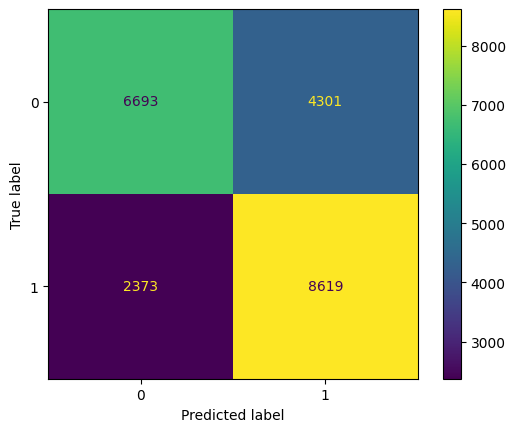

In [42]:
# Definindo uma classe para automatizar o processo de substituir valores outliers
class OutlierReplacer(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=1.5):
        self.threshold = threshold
        self.means = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.means = X.mean()
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        Q1 = X.quantile(.25)
        Q3 = X.quantile(.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - self.threshold * IQR
        limite_superior = Q3 + self.threshold * IQR
        return X.mask((X < limite_inferior) | (X > limite_superior), self.means, axis=1).values

# Criando um pipeline para transformar as variáveis contínuas
# Imputer - substitui qualquer valor missing com a média da coluna
# Outlier - substitui qualquer valor outlier com a média da coluna
# Scaler - padroniza os valores para a mesma escala
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('outlier', OutlierReplacer()),
    ('scaler', StandardScaler())
])

# Criando um pipeline para transformar as variáveis categóricas
# Imputer - substitui qualquer valor missing com a média da coluna
# Encoder - aplica one-hot encoding nas variáveis
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Criando um pipeline para processamento dos dados de acordo com seu tipo
# Num - aplica o processamento de variáveis contínuas à variáveis contínuas
# Cat - aplica o processamento de variáveis categóricas à variáveis categóricas
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Seleciona as melhores variáveis com base no modelo de RandomForestClassifier
feature_selection = SelectFromModel(RandomForestClassifier(n_estimators=100))

# Cria objeto para reduzir a dimensão da base
pca = PCA(n_components=3)

# Cria o modelo de regressão logística
model = LogisticRegression()

# Pipeline para o processamento, seleção de features, redução de dimensionalidade e treinamento do modelo
# Preprocessor - aplica o pipeline de processamento dos dados
# Feature_selection - seleciona as melhores variáveis
# Pca - reduz a dimensão da base
# Classifier - treina o modelo
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', feature_selection),
    ('pca', pca),
    ('classifier', model)
])

# Criando uma cópia dos dados originais
data_copy = data.copy()

# Separando as classes majoritárias das minoritárias
majority_class = data_copy[data_copy['mau'] == 0]
minority_class = data_copy[data_copy['mau'] == 1]

# Balanceando os dados com downsampling
majority_downsampled = resample(majority_class, replace=False, n_samples=len(minority_class), random_state=412)

# Criando a base balanceada
balanced_data = pd.concat([majority_downsampled, minority_class])
balanced_data = balanced_data.sample(frac=1, random_state=412).reset_index(drop=True)

# Separando os dados em variáveis independentes (X) e dependente (y)
X_matrix_balanced = balanced_data.drop(['data_ref', 'index', 'mau'], axis=1)
y_true_balanced = balanced_data['mau'].astype(np.int64)

# Separando os dados em base de treino e teste
X_matrix_tr, X_matrix_ts, y_true_tr, y_true_ts = train_test_split(X_matrix_balanced, y_true_balanced, test_size=0.3, random_state=412)

# Ajustando o modelo aos dados de treino
pipeline.fit(X_matrix_tr, y_true_tr)

# Criando previsões com o modelo treinado
predictions = pipeline.predict(X_matrix_ts)
proba_predictions = pipeline.predict_proba(X_matrix_ts)

# Métricas de avaliação do modelo
accuracy = accuracy_score(y_true_ts, predictions)
auc_score = roc_auc_score(y_true_ts, predictions)
gini = 2 * auc_score - 1
fpr, tpr, _ = roc_curve(y_true_ts, proba_predictions[:, 1])
ks = max(tpr - fpr)

print('='*75)
print('Métricas do modelo na base de teste'.center(75))
print('='*75)
print(f'Acurácia do modelo na base de teste: {accuracy:.2%}')
print(f'AUC do modelo na base de teste: {auc_score:.2%}')
print(f'Coeficiente de Gini do modelo na base de teste: {gini:.2%}')
print(f'KS do modelo na base de teste: {ks:.4f}')

# Criando e plotando matrix de confusão na base de teste
cm = confusion_matrix(y_true_ts, predictions)
cm_disp = ConfusionMatrixDisplay(cm)
cm_disp.plot()
plt.show()

# b - Pycaret na base de dados 

Utilize o pycaret para pre processar os dados e rodar o modelo **lightgbm**. Faça todos os passos a passos da aula e gere os gráficos finais. E o pipeline de toda a transformação.



In [43]:
from pycaret.classification import *

# Criando setup do pycaret usando a amostra 
pycaret_setup = setup(data=sample_data, target='mau', session_id=412)

,Description,Value
0,Session id,412
1,Target,mau
2,Target type,Binary
3,Original data shape,"(120000, 13)"
4,Transformed data shape,"(120000, 30)"
5,Transformed train set shape,"(84000, 30)"
6,Transformed test set shape,"(36000, 30)"
7,Numeric features,5
8,Categorical features,7
9,Preprocess,True


In [55]:
# Criando o modelo
lightgbm_model = create_model('lightgbm', fold=5)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9380,0.7510,0.0000,0.0000,0.0000,-0.0014,-0.0068
1,0.9386,0.7698,0.0029,0.3333,0.0058,0.0047,0.0263
2,0.9386,0.7505,0.0010,0.2000,0.0019,0.0013,0.0100
3,0.9386,0.7485,0.0029,0.3333,0.0058,0.0047,0.0263
4,0.9383,0.7751,0.0029,0.2143,0.0058,0.0041,0.0184
Mean,0.9384,0.7590,0.0019,0.2162,0.0038,0.0027,0.0148
Std,0.0002,0.0112,0.0012,0.1220,0.0024,0.0024,0.0124


In [56]:
# Visualizando hiper-parâmetros do modelo criado
print(lightgbm_model)

LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=412, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)


In [57]:
# Ajustando o modelo
tuned_model = tune_model(lightgbm_model, fold=5)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9387,0.7550,0.0010,0.3333,0.0019,0.0016,0.0152
1,0.9386,0.7733,0.0010,0.2500,0.0019,0.0015,0.0121
2,0.9387,0.7533,0.0010,0.3333,0.0019,0.0016,0.0152
3,0.9389,0.7550,0.0019,1.0000,0.0039,0.0036,0.0427
4,0.9389,0.7768,0.0019,1.0000,0.0039,0.0036,0.0427
Mean,0.9388,0.7627,0.0014,0.5833,0.0027,0.0024,0.0256
Std,0.0001,0.0102,0.0005,0.3416,0.0010,0.0010,0.0140


Fitting 5 folds for each of 10 candidates, totalling 50 fits


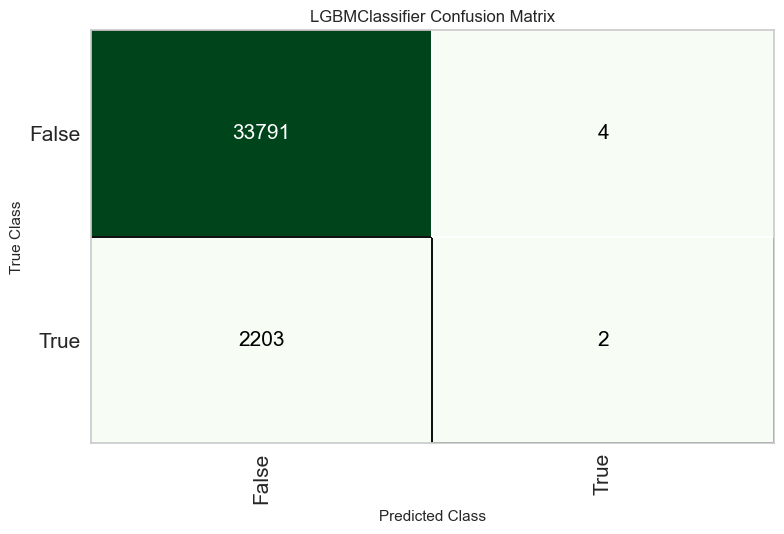

In [59]:
# Visualizando matrix de confusão
plot_model(tuned_model, plot='confusion_matrix')

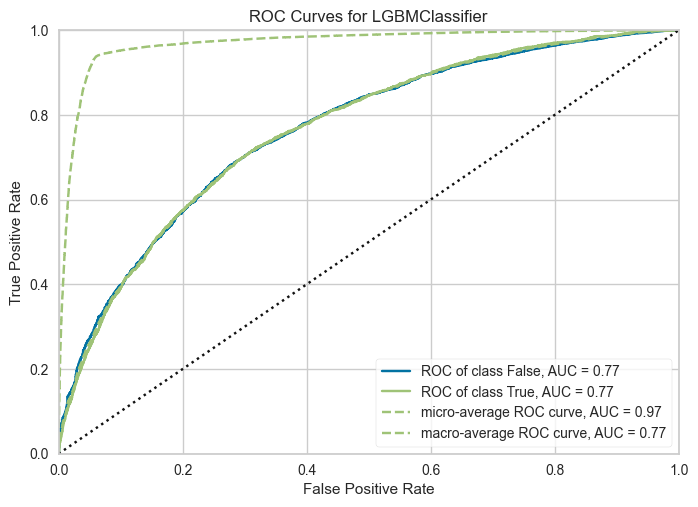

In [61]:
# Visualizando Area Under the Curve
plot_model(tuned_model, plot='auc')

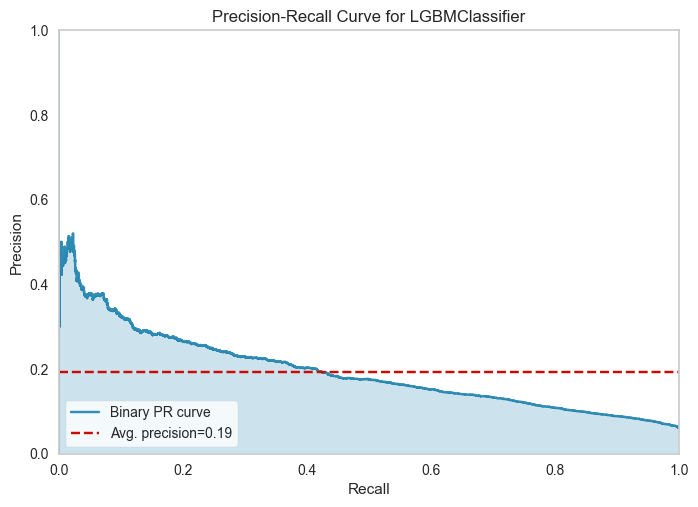

In [62]:
# Visualizando curva de Precision-recall
plot_model(tuned_model, plot='pr')

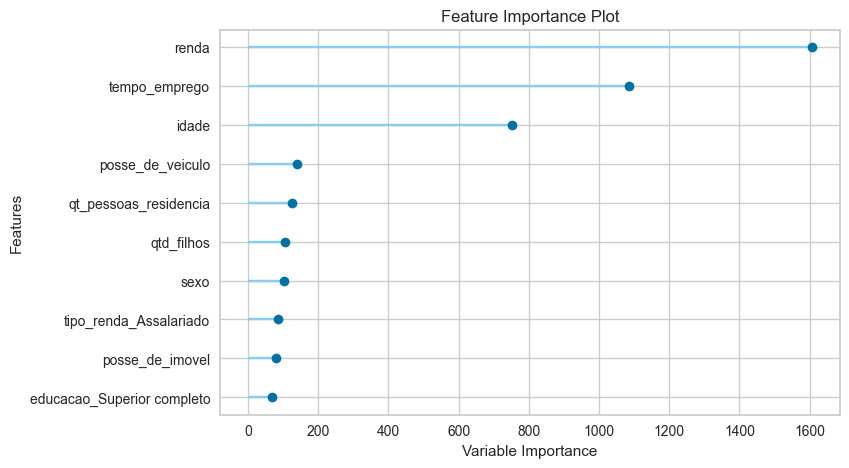

In [63]:
# Visualizando importância dos features
plot_model(tuned_model, plot='feature')

In [65]:
# Criando previsões do modelo
predict_model(tuned_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9387,0.7650,0.0009,0.3333,0.0018,0.0015,0.0146


[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0


,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau,prediction_label,prediction_score
60813,M,S,S,1,Empresário,Médio,Casado,Com os pais,28,0.816438,3.0,5911.850098,False,0,0.9243
205529,M,S,S,1,Assalariado,Superior incompleto,Casado,Com os pais,35,0.926027,3.0,10539.580078,False,0,0.9518
527622,F,S,N,1,Empresário,Médio,Solteiro,Governamental,32,13.652055,2.0,10696.160156,False,0,0.9813
330683,F,N,S,0,Pensionista,Médio,Casado,Casa,59,7.747993,2.0,24759.650391,False,0,0.9839
460031,M,N,S,1,Servidor público,Superior completo,Casado,Casa,30,1.030137,3.0,12927.309570,False,0,0.9539
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
460777,F,N,S,0,Servidor público,Superior completo,Casado,Casa,52,6.671233,2.0,43456.488281,False,0,0.9860
132264,M,S,N,2,Assalariado,Superior completo,Casado,Casa,28,2.035616,4.0,3744.129883,False,0,0.8815
280154,F,N,S,0,Pensionista,Médio,Casado,Estúdio,55,7.747993,2.0,5860.709961,False,0,0.9110
271270,M,S,S,0,Assalariado,Superior incompleto,Solteiro,Casa,29,4.663014,1.0,4936.720215,False,0,0.9198


A acurácia do modelo treinado na base de treino e testado na base de teste é de **93.87%**, indicando um modelo aparentemente bom, contudo, os parâmetros de **Recall**, **Precision** e **F1** são muito baixos, o que revela que o modelo, apesar de conseguir classificar clientes bons, não tem poder discriminatório para classificar clientes maus, o que faz sentido dado a base desbalanceada de dados usados na criação do modelo.

In [66]:
# Finalizando o modelo
final_model = finalize_model(tuned_model)

# Visualizando pipeline do modelo
print(final_model)

In [68]:
# Criando previsões do modelo
predict_model(final_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9389,0.7990,0.0032,0.8750,0.0063,0.0059,0.0506


[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0


,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau,prediction_label,prediction_score
60813,M,S,S,1,Empresário,Médio,Casado,Com os pais,28,0.816438,3.0,5911.850098,False,0,0.9164
205529,M,S,S,1,Assalariado,Superior incompleto,Casado,Com os pais,35,0.926027,3.0,10539.580078,False,0,0.9114
527622,F,S,N,1,Empresário,Médio,Solteiro,Governamental,32,13.652055,2.0,10696.160156,False,0,0.9749
330683,F,N,S,0,Pensionista,Médio,Casado,Casa,59,7.747993,2.0,24759.650391,False,0,0.9838
460031,M,N,S,1,Servidor público,Superior completo,Casado,Casa,30,1.030137,3.0,12927.309570,False,0,0.9718
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
460777,F,N,S,0,Servidor público,Superior completo,Casado,Casa,52,6.671233,2.0,43456.488281,False,0,0.9882
132264,M,S,N,2,Assalariado,Superior completo,Casado,Casa,28,2.035616,4.0,3744.129883,False,0,0.9002
280154,F,N,S,0,Pensionista,Médio,Casado,Estúdio,55,7.747993,2.0,5860.709961,False,0,0.9400
271270,M,S,S,0,Assalariado,Superior incompleto,Solteiro,Casa,29,4.663014,1.0,4936.720215,False,0,0.9278


As previsões acima criadas com toda a base de dados, apresentam resultados levemente melhores, com os parâmetros de **Recall**, **Precision** e **F1** mais altos, o que significa que esse modelo é levemente melhor que o modelo criado com apenas a base de treino.

In [69]:
# Criando previsões com dados não vistos
unseen_predictions = predict_model(final_model, data=data_unseen)
unseen_predictions.head(5)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.8532,0.7349,0.0059,0.4558,0.0116,0.0079,0.0380


[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0


,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau,prediction_label,prediction_score
600000,2016-01-01,8906,F,S,S,2,Assalariado,Superior completo,Casado,Casa,38,7.383562,4.0,2969.489990,True,0,0.8764
600001,2016-01-01,5063,F,N,S,0,Assalariado,Médio,Casado,Casa,55,8.471232,2.0,6278.370117,False,0,0.9486
600002,2016-01-01,16401,M,S,S,1,Assalariado,Médio,União,Casa,39,8.884932,3.0,14010.179688,False,0,0.9705
600003,2016-01-01,6786,F,N,S,1,Assalariado,Médio,União,Com os pais,31,1.794520,3.0,2875.810059,False,0,0.8608
600004,2016-01-01,13466,M,S,N,0,Assalariado,Médio,Casado,Casa,27,7.019178,2.0,2737.189941,False,0,0.8726


Por fim temos o desempenho final do modelo criado, usando a base de dados não vista e removidas da base antes da modelagem. O modelo final apresenta uma queda na acurácia e em outros parâmetros, contudo também é o modelo com o melhor **F1**, portanto, é o modelo com o melhor poder de discrimanação dos três.